In [2]:
from scania.dataset import ScaniaDataModule

data_dir = "data/Scania_component_X"
cache_dir = "scania_cache"

scania_data_module = ScaniaDataModule(
    data_dir=data_dir,
    batch_size=128,
    sequence_len=32,
    seed=42,
    val_rate=0.2,
    test_rate=0.1,
    stratify=True,
    norm_type="z-score",
    shuffle_loader=False,
    cache_dir=cache_dir,
    num_workers=0,
    pin_memory=True,
    return_sequence_label=False,
)

scania_data_module.setup()

test_dataloader = scania_data_module.test_dataloader()


[Scania] Loading preprocessed data from cache: scania_cache


C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


tensor([[176.4000],
        [125.8000],
        [ 98.8000],
        [ 36.0000],
        [ 71.6000],
        [ 66.4000],
        [  0.6000],
        [102.4000],
        [ 12.8000],
        [146.6000],
        [ 21.0000],
        [  8.4000],
        [ 56.2000],
        [ 12.8000],
        [ 57.4000],
        [ 34.4000],
        [ 60.6000],
        [ 69.6000],
        [ 93.0000],
        [ 11.6000],
        [ 32.6000],
        [128.8000],
        [100.8000],
        [ 19.4000],
        [ 59.4000],
        [181.6000],
        [129.4000],
        [ 83.2000],
        [ 18.6000],
        [153.8000],
        [145.8000],
        [ 39.2000],
        [ 33.2000],
        [ 60.2000],
        [161.4000],
        [ 88.0000],
        [ 28.0000],
        [  7.4000],
        [  0.2000],
        [ 35.0000],
        [133.4000],
        [ 85.6000],
        [  5.6000],
        [ 83.0000],
        [104.0000],
        [ 10.8000],
        [  0.6000],
        [ 25.2000],
        [  2.2000],
        [ 42.2000],


In [9]:
import numpy as np

for x, y in test_dataloader:
    print(len(y))

label_array = scania_data_module.test_set.label_array
id_array = scania_data_module.test_set.id_array

for i in range(len(label_array)):
    if not np.isnan(label_array[i]):
        print(f"id : {id_array[i]} - RUL : {label_array[i]}")


128
99
id : 84 - RUL : 176.40000000000003
id : 300 - RUL : 125.79999999999998
id : 310 - RUL : 98.79999999999995
id : 485 - RUL : 35.99999999999997
id : 522 - RUL : 71.6
id : 540 - RUL : 66.4
id : 785 - RUL : 0.5999999999999943
id : 839 - RUL : 102.4
id : 841 - RUL : 12.800000000000011
id : 1044 - RUL : 146.60000000000002
id : 1159 - RUL : 21.0
id : 1173 - RUL : 8.399999999999977
id : 1225 - RUL : 56.19999999999999
id : 1343 - RUL : 12.799999999999983
id : 1497 - RUL : 57.39999999999998
id : 1635 - RUL : 34.400000000000006
id : 1643 - RUL : 60.599999999999994
id : 1709 - RUL : 69.6
id : 1850 - RUL : 93.0
id : 2199 - RUL : 11.600000000000023
id : 2248 - RUL : 32.599999999999966
id : 2342 - RUL : 128.8
id : 2393 - RUL : 100.79999999999998
id : 2450 - RUL : 19.400000000000034
id : 2476 - RUL : 59.400000000000006
id : 2664 - RUL : 181.59999999999997
id : 2752 - RUL : 129.4
id : 3320 - RUL : 83.19999999999999
id : 3434 - RUL : 18.599999999999994
id : 3559 - RUL : 153.8
id : 3727 - RUL : 145

In [42]:
dataloader = scania_data_module.train_dataloader()

i = 1

print(len(dataloader))

for x, y in dataloader:
    print("First sequence of first batch: ")
    for sequence in x[0]:
        print(sequence)

    print("First sequence of second batch: ")
    for sequence in x[1]:
        print(sequence)

    break

df = scania_data_module.train_set.df

df = df[df['is_censored'] == 0]

df.head()


234
First sequence of first batch: 
tensor([-0.8567, -0.6434, -0.8841, -0.4413, -0.1987, -0.8950, -0.2614, -0.7243])
tensor([ 0.5040,  1.4853,  0.4102,  0.4243, -0.1157,  0.2370, -0.2614, -0.1716])
tensor([-0.1001,  0.4609, -0.1591,  0.2796, -0.1599, -0.2379, -0.2614, -0.3151])
tensor([-0.6196, -0.3809, -0.6590, -0.2696, -0.1987, -0.6916, -0.2614, -0.6032])
tensor([ 0.5414,  1.5211,  0.4510,  0.8607, -0.0897,  0.3056, -0.2614, -0.0087])
tensor([-0.8567, -0.6434, -0.8841, -0.4410, -0.1987, -0.8950, -0.2614, -0.7243])
tensor([-0.5260, -0.1950, -0.5610, -0.2010, -0.1923, -0.6015, -0.2614, -0.5388])
tensor([ 0.8000,  1.6417,  0.7148,  0.4096, -0.1732,  0.5435, -0.2614,  0.1325])
tensor([ 1.1934,  2.6182,  1.0969,  0.1913, -0.1732,  0.9203, -0.2614,  0.4761])
tensor([-0.6862, -0.2642, -0.7212, -0.3674, -0.1987, -0.7478, -0.2614, -0.6312])
tensor([-0.4623, -0.1342, -0.4950, -0.2279, -0.1987, -0.5206, -0.2614, -0.4112])
tensor([-0.8544, -0.6387, -0.8793, -0.4413, -0.1987, -0.8849, -0.2614, -0

C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


,vehicle_id,time_step,171_0,666_0,427_0,837_0,309_0,835_0,370_0,100_0,length_of_study_time_step,is_censored,rul_lower_bound,rul
395,22,3,0,0,0,0,0,0,0,0,190,0,187,187
396,22,7,0,1,0,0,0,0,0,0,190,0,183,183
397,22,10,0,0,0,0,0,0,0,0,190,0,180,180
398,22,12,0,0,0,0,0,0,0,0,190,0,178,178
399,22,17,0,1,0,0,0,0,0,0,190,0,173,173


In [8]:
import numpy as np

vehicules_ids = np.array([10, 12, 14, 14])

starts = np.concatenate(([0], np.flatnonzero(np.diff(vehicules_ids) != 0) + 1))

print(np.diff(vehicules_ids))
print(np.flatnonzero(np.diff(vehicules_ids) != 0))
print(starts)

[2 2 0]
[0 1]
[0 1 2]


In [36]:
def sequence_indexes(subset_first_index, subset_last_index,window_size, only_last_window=False):
    '''
    Compute the indexes of the sequences in the dataset
    x: features
    y: target
    window_size: size of the window in number of observations
    '''
    if only_last_window:
        end_idx = [subset_last_index]
    else:
        end_idx = np.arange(start=subset_first_index,stop=subset_last_index+1,dtype=int)

    start_idx = np.vectorize(lambda x: max(subset_first_index,x-window_size))(end_idx)
    return start_idx, end_idx

subset = df[df['vehicle_id'] == 22]

sequence_starting_indexes_list = []
sequence_ending_indexes_list = []

subset_first_index = subset.index[0]
subset_last_index = subset.index[-1]
# print(f'Vehicle {id} first index: {subset_first_index} last index: {subset_last_index}')

# get the statring and ending indexes of the sequences for the subset
start_idx, end_idx = sequence_indexes(subset_first_index,subset_last_index,32) # get the indexes of the sequences for one subset

# append the indexes to the lists
sequence_starting_indexes_list.extend(start_idx)
sequence_ending_indexes_list.extend(end_idx)

print(sequence_starting_indexes_list)
print(sequence_ending_indexes_list)

[np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(395), np.int64(396), np.int64(397), np.int64(398), np.int64(399), np.int64(400), np.int64(401), np.int64(402), np.int64(403), np.int64(404), np.int64(405), np.int64(406), np.int64(407), np.int64(408), np.int64(409), np.int64(410), np.int64(411), np.int64(412), np.int64(413)]
[np.int64(395), np.int64(396), np.int64(397), np.int64(398), np.int64(399), np.int64(400), np.int64(401), np.int64(402), np.int64(403), np.int64(404), np.int64(405), np.int64(406), np.int64(407), np.int64(408), np.int64(409), np.int64

In [19]:
import pandas as pd

df_train = pd.read_csv("outputs/train.csv")
df_val = pd.read_csv("outputs/val.csv")
df_test = pd.read_csv("outputs/test.csv")

ids_train = df_train['vehicle_id'].unique()
ids_val = df_val['vehicle_id'].unique()
ids_test = df_test['vehicle_id'].unique()

print(f"Train : {len(ids_train)}")
print(f"Val : {len(ids_val)}")
print(f"Test : {len(ids_test)}")

print(f"Test len : {len(df_test)}")

Train : 16487
Val : 4709
Test : 2354
Test len : 106118


In [12]:
ids_train_not_censored = df_train.loc[df_train['is_censored'] == 0, 'vehicle_id'].unique()
ids_val_not_censored = df_val.loc[df_train['is_censored'] == 0, 'vehicle_id'].unique()
ids_test_not_censored = df_test.loc[df_train['is_censored'] == 0, 'vehicle_id'].unique()

print(f"Train : {len(ids_train_not_censored)}")
print(f"Val : {len(ids_val_not_censored)}")
print(f"Test : {len(ids_test_not_censored)}")

print(f"Train len : {len(df_train.loc[df_train['is_censored'] == 0])}")
print(f"Val len : {len(df_val.loc[df_train['is_censored'] == 0])}")
print(f"Test len : {len(df_test.loc[df_train['is_censored'] == 0])}")

Train : 1591
Val : 973
Test : 541
Train len : 74111
Val len : 27075
Test len : 15178


In [28]:
test_dataloader = scania_data_module.test_dataloader()

id_array_test = scania_data_module.test_set.id_array
sequence_array_test = scania_data_module.test_set.sequence_array

for idx, id in enumerate(id_array_test):
    if id == 55:
        for sequence in sequence_array_test[idx]:
            print(sequence)
        # print(f"Id : {id} - taille séquence : {len(sequence_array_test[idx])}")

length = 0

for x, y in test_dataloader:
    length += y.size()[0]

print(length)

[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.85665458 -0.64343098 -0.88413123 -0.44126771 -0.19868448 -0.89500839
 -0.26140025 -0.72431696]
[-0.856654

C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [11]:
print("################## TRAIN ##################")

group_by_ids_train = df_train[df_train['is_censored'] == 0].groupby('vehicle_id').size().reset_index(name='row_count')

for i in range(len(group_by_ids_train['vehicle_id'])):
    id = group_by_ids_train['vehicle_id'][i]
    count = group_by_ids_train['row_count'][i]

    # print(f"id : {id} - row number : {count}")

print("################## TEST ##################")

group_by_ids_test = df_test[df_test['is_censored'] == 0].groupby('vehicle_id').size().reset_index(name='row_count')

ids_with_more_than_200_row = []

for i in range(len(group_by_ids_test['vehicle_id'])):
    id = group_by_ids_test['vehicle_id'][i]
    count = group_by_ids_test['row_count'][i]

    # print(f"id : {id} - row number : {count}")
    if count >= 200:
        ids_with_more_than_200_row.append(id)

print(f"Ids with more than 200 rows : {ids_with_more_than_200_row}")

################## TRAIN ##################
################## TEST ##################
Ids with more than 200 rows : []


C:\Users\Epulapp\AppData\Local\Temp\ipykernel_26888\3771746085.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  counts_test = df_test[df_train['is_censored'] == 0].groupby('vehicle_id').size()


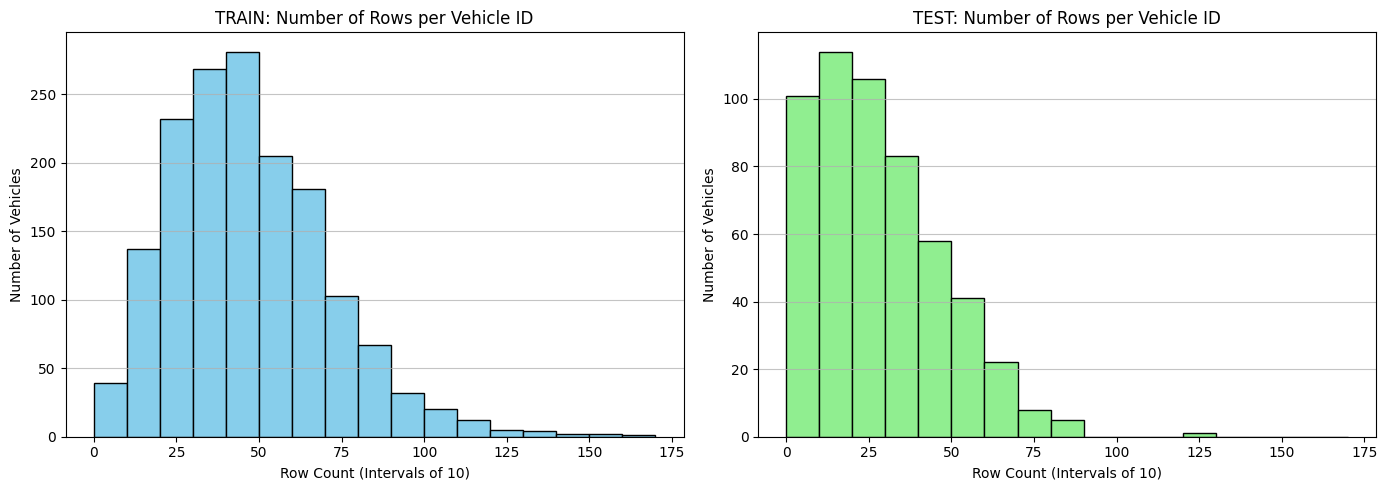

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Get the row counts (you already had the right idea with groupby!)
counts_train = df_train[df_train['is_censored'] == 0].groupby('vehicle_id').size()
counts_test = df_test[df_train['is_censored'] == 0].groupby('vehicle_id').size()

# 2. Find the overall maximum row count to set our bin limits correctly
max_count = max(counts_train.max(), counts_test.max())

# 3. Create the bins in intervals of 10 (from 0 up to the maximum count + 10)
# This fulfills your requirement for "interval of 10"
bins_list = range(0, int(max_count) + 10, 10)

# 4. Set up the figure with 2 subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- TRAIN HISTOGRAM ---
axes[0].hist(counts_train, bins=bins_list, color='skyblue', edgecolor='black')
axes[0].set_title('TRAIN: Number of Rows per Vehicle ID')
axes[0].set_xlabel('Row Count (Intervals of 10)')
axes[0].set_ylabel('Number of Vehicles')
axes[0].grid(axis='y', alpha=0.75)

# --- TEST HISTOGRAM ---
axes[1].hist(counts_test, bins=bins_list, color='lightgreen', edgecolor='black')
axes[1].set_title('TEST: Number of Rows per Vehicle ID')
axes[1].set_xlabel('Row Count (Intervals of 10)')
axes[1].set_ylabel('Number of Vehicles')
axes[1].grid(axis='y', alpha=0.75)

# Display the plots neatly
plt.tight_layout()
plt.show()

In [16]:
df_test_not_censored = df_test[df_test['is_censored'] == 0]

df_test_not_censored['RUL'] =  df_test_not_censored['length_of_study_time_step'] - df_test_not_censored['time_step']

df_with_last_readout = df_test_not_censored.sort_values(["vehicle_id", "time_step"]).drop_duplicates("vehicle_id", keep="last")

df_with_last_readout.to_csv("test_with_last_readout.csv")

     vehicle_id  time_step     171_0     666_0     427_0     837_0     309_0  \
146          84        2.2 -0.856655 -0.643431 -0.884131 -0.441268 -0.198684   
147          84        3.8 -0.447173 -0.504924 -0.512139 -0.411537 -0.198684   
148          84        8.0  0.004513 -0.483628 -0.083696 -0.413989 -0.192302   
149          84        8.6 -0.854911 -0.643431 -0.880232 -0.441268 -0.198684   
150          84        9.0 -0.719812 -0.612424 -0.753403 -0.441268 -0.198684   

        835_0   370_0     100_0  length_of_study_time_step  is_censored  
146 -0.895008 -0.2614 -0.724317                      311.6            0  
147 -0.566894 -0.2614 -0.551093                      311.6            0  
148 -0.166273 -0.2614 -0.258552                      311.6            0  
149 -0.884668 -0.2614 -0.692610                      311.6            0  
150 -0.777265 -0.2614 -0.655641                      311.6            0  


C:\Users\Epulapp\AppData\Local\Temp\ipykernel_26888\719728154.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test_not_censored['RUL'] =  df_test_not_censored['length_of_study_time_step'] - df_test_not_censored['time_step']


In [41]:
import pandas as pd
import torch
import torch.nn as nn

# df_predictions = pd.read_csv("outputs/model-transformer-scania-2026-07-09_12-24-15/predictions_transformer_test_scania.csv")
df_predictions = pd.read_csv("predictions_transformer_scania.csv")

print(df_predictions.head())

input_tensor = torch.tensor(df_predictions["predictions"].values)
target_tensor = torch.tensor(df_predictions["targets"].values)

mae = torch.mean(torch.abs(target_tensor - input_tensor))

# print result
print("\n MAE loss: ", mae)

   targets  predictions
0    264.2    175.34058
1    261.4    174.65425
2    259.8    174.81255
3    258.8    175.22330
4    257.4    175.59820

 MAE loss:  tensor(61.6828, dtype=torch.float64)


In [18]:
import numpy as np
import pandas as pd

# Fraction of the *last* readouts to drop for each non-censored vehicle.
# Dropping the end of a run-to-failure trajectory makes the last retained
# readout further from the failure event, i.e. gives a larger RUL to predict.
DROP_LAST_FRACTION = 0.4

df_test = pd.read_csv("outputs/test.csv")

# Censored vehicles are kept as-is: their last readout is a suspension, not a
# failure, so trimming it would not increase a meaningful RUL.
censored = df_test[df_test["is_censored"] == 1]
not_censored = df_test[df_test["is_censored"] == 0].copy()

# Order readouts in time within each vehicle so "last" is well defined.
not_censored = not_censored.sort_values(["vehicle_id", "time_step"])

# For each vehicle keep only the first (1 - DROP_LAST_FRACTION) of its readouts.
counts = not_censored.groupby("vehicle_id")["time_step"].transform("size")
position = not_censored.groupby("vehicle_id").cumcount()  # 0-based, chronological
n_keep = np.maximum(1, np.round(counts * (1 - DROP_LAST_FRACTION)).astype(int))
not_censored_reduced = not_censored[position < n_keep]

# Recombine censored + trimmed non-censored and restore a clean ordering.
df_test_reduced = pd.concat([censored, not_censored_reduced]).sort_values(
    ["vehicle_id", "time_step"]
)

df_test_reduced.to_csv("outputs/test_reduced.csv", index=False)

print(f"Original rows             : {len(df_test)}")
print(f"Reduced rows              : {len(df_test_reduced)}")
print(
    f"Non-censored rows before/after: {len(not_censored)} -> {len(not_censored_reduced)}"
    f" ({len(not_censored_reduced) / len(not_censored):.0%} kept)"
)


Original rows             : 110333
Reduced rows              : 106118
Non-censored rows before/after: 10530 -> 6315 (60% kept)


In [40]:
import numpy as np
import pandas as pd
import torch
from lightning import Trainer

from models import TransformerEncoder_LSTM_1, Simple_LSTM
from scania.dataset import ScaniaDataModule
from scania.lightning_module import BasicLightningModule

# IMPORTANT: these must match the values used when the checkpoint was trained
# (scania/config/default/transformer.json + the datamodule feature count).
# The transformer was trained with sequence_len=200, so re-create the datamodule
# with the same window size here.
sequence_len = 32

scania_data_module = ScaniaDataModule(
    data_dir="data/Scania_component_X",
    seed=42,
    val_rate=0.2,
    test_rate=0.1,
    stratify=True,
    norm_type="z-score",
    shuffle_loader=False,
    cache_dir="outputs",
    num_workers=0,
    pin_memory=False,
    return_sequence_label=False,
    batch_size=128,
    sequence_len=sequence_len,
)

scania_data_module.setup()

feature_num = len(scania_data_module.feature_cols)

# Same model_params as scania/config/default/transformer.json
model_kwargs_transformer = {
    "transformer_encoder_head_num": 8,
    "hidden_dim": 256,
    "lstm_num_layers": 5,
    "lstm_dropout": 0.3,
    "fc_layer_dim": 128,
    "fc_dropout": 0.2,
    "sequence_len": sequence_len,
    "feature_num": feature_num,
}

model_kwargs_lstm = {
    "sequence_len": sequence_len,
    "feature_num": feature_num,
    "hidden_dim": 256,
    "lstm_num_layers": 3,
    "lstm_dropout": 0.3,
    "fc_layer_dim": 128,
    "fc_dropout": 0.2
}

# The nn.Module is NOT stored in the checkpoint (BasicLightningModule calls
# save_hyperparameters(ignore=['model'])), so we must rebuild the exact same
# architecture and pass it as `model=` to load_from_checkpoint.
model_for_reload = TransformerEncoder_LSTM_1(**model_kwargs_transformer)
# model_for_reload = Simple_LSTM(**model_kwargs_lstm)
checkpoint_path = (
    "checkpoints/model-transformer-scania-2026-07-09_12-24-15/"
    "checkpoint-epoch=67-val_rmse=63.2821.ckpt"
)
# checkpoint_path = (
#     "checkpoints/model-lstm-scania-2026-07-09_12-02-31/"
#     "checkpoint-epoch=50-val_rmse=32.6744.ckpt"
# )

lightning_module_with_trained_model = BasicLightningModule.load_from_checkpoint(
    checkpoint_path,
    model=model_for_reload,
)

lightning_module_with_trained_model.eval()

trainer = Trainer(accelerator="auto")

outputs = trainer.predict(lightning_module_with_trained_model, datamodule=scania_data_module)

predictions = torch.cat([preds for preds, _ in outputs]).cpu().numpy().flatten()
targets = torch.cat([y for _, y in outputs]).cpu().numpy().flatten()

df = pd.DataFrame({
    "targets": targets,
    "predictions": predictions,
})

csv_path = "predictions_transformer_scania.csv"
# csv_path = "predictions_lstm_scania.csv"
df.to_csv(csv_path, index=False)

rmse = float(np.sqrt(np.mean((targets - predictions) ** 2)))
print(f"Test RMSE: {rmse}")


[Scania] Loading preprocessed data from cache: outputs


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\lightning\pytorch\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\Epulapp\PycharmProjects\SurvivalAnalysisScaniaComponentX\.venv\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider in

Predicting DataLoader 0: 100%|██████████| 9/9 [00:01<00:00,  4.85it/s]
Test RMSE: 73.80802154541016


In [37]:
from C_MAPSS.dataset.CMAPSSLoader import CMAPSSLoader

train_dataset, test_dataset, valid_dataset = CMAPSSLoader.get_datasets(
    dataset_root="data/C_MAPSS",
    sub_dataset="FD001",
    sequence_len=32,
    seed=42,
    max_rul=125,
    return_sequence_label=False,
    norm_type="z-score",
    cluster_operations=True,
    norm_by_operations=True,
    include_cols=[],
    exclude_cols=[],
    return_id=False,
    validation_rate=0.2,
    use_only_final_on_test=True,
    use_max_rul_on_test=True,
    use_max_rul_on_valid=True,
    percent_of_broken_data=0.8,
    percent_of_censored_data=0.9,
)

train_dataset.df.to_csv("train_dataset_v1_0.9_0.8.csv", index=False)

train_dataset_2, test_dataset_2, valid_dataset_2 = CMAPSSLoader.get_datasets(
    dataset_root="data/C_MAPSS",
    sub_dataset="FD001",
    sequence_len=32,
    seed=42,
    max_rul=125,
    return_sequence_label=False,
    norm_type="z-score",
    cluster_operations=True,
    norm_by_operations=True,
    include_cols=[],
    exclude_cols=[],
    return_id=False,
    validation_rate=0.2,
    use_only_final_on_test=True,
    use_max_rul_on_test=True,
    use_max_rul_on_valid=True,
    percent_of_broken_data=0.8,
    percent_of_censored_data=0.9,
)
train_dataset_2.df.to_csv("train_dataset_v2_0.9_0.8.csv", index=False)

In [36]:
import numpy as np

df_train_v1 = pd.read_csv("train_dataset_v1_0.9_0.8.csv")
df_train_v2 = pd.read_csv("train_dataset_v2_0.9_0.6.csv")

ids_v1 = df_train_v1['id'].unique()
ids_v2 = df_train_v2['id'].unique()

ids_v1 = np.sort(ids_v1)
ids_v2 = np.sort(ids_v2)

for i in range(len(ids_v1)):
    id_v1 = ids_v1[i]
    id_v2 = ids_v2[i]

    if id_v1 != id_v2:
        print(f"id_v1 : {ids_v1[i]} - id_v2 : {ids_v2[i]}")


[  2   3   4   6   7   8   9  10  12  14  15  16  17  18  20  21  22  24
  25  26  27  28  29  30  33  35  36  37  38  39  41  42  43  44  47  48
  49  50  51  52  53  55  56  57  58  59  60  61  62  63  64  65  66  67
  68  69  70  72  73  75  76  79  80  82  83  85  86  87  88  89  90  92
  93  94  95  96  97  98  99 100]
